# ToneTrade: does geopolitical risk help time defence stocks?

The question: does the news-based Geopolitical Risk index (GPR acts and threats) add
information about 5-day moves in ITA, the US aerospace and defence ETF, beyond ITA's
own price history and oil?

**Hypothesis.** Days with more coverage of geopolitical acts and threats are followed
by different defence-stock returns, so a model given GPR predicts ITA's next 5-day
move better than the same model without it.

- **Supported if** the GPR models beat their `no_gpr` versions out of sample, and
  their buy calls are right more often than the base rate.
- **Not supported if** adding GPR makes no difference, or the models do no better
  than always predicting the more common outcome. A clean negative result is a valid
  outcome.

This notebook is generated from `scripts/model.py` with `pixi run notebook`; edit
the script, not the notebook (see `scripts/README.md`). It reads committed snapshots
of prices (to 6 October 2026) and GPR, so rerunning it reproduces these results exactly.

In [1]:
"""ToneTrade model script in percent-format (# %%) cells.

Builds prices, GPR features and labels, fits XGBoost and a logistic baseline with
walk-forward evaluation, and backtests the signal against buy-and-hold ITA.
`pixi run notebook` renders it to scripts/model.ipynb (see scripts/README.md).
"""

from itertools import product

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

import tonetrade as tt


pd.set_option("display.width", 120)

## Data and features

One row per ITA trading day. Prices are ITA and Brent crude. GPR acts and threats are
daily counts of newspaper coverage of geopolitical events and threats; each is a
7-day mean, lagged a day because it's built from that day's papers.

Features: ITA and Brent returns over 5, 20 and 60 days, ITA 20-day volatility,
ITA's distance from its 50-day mean, and the two GPR series. Every window ends at
day *t*, so nothing uses information from after *t*.

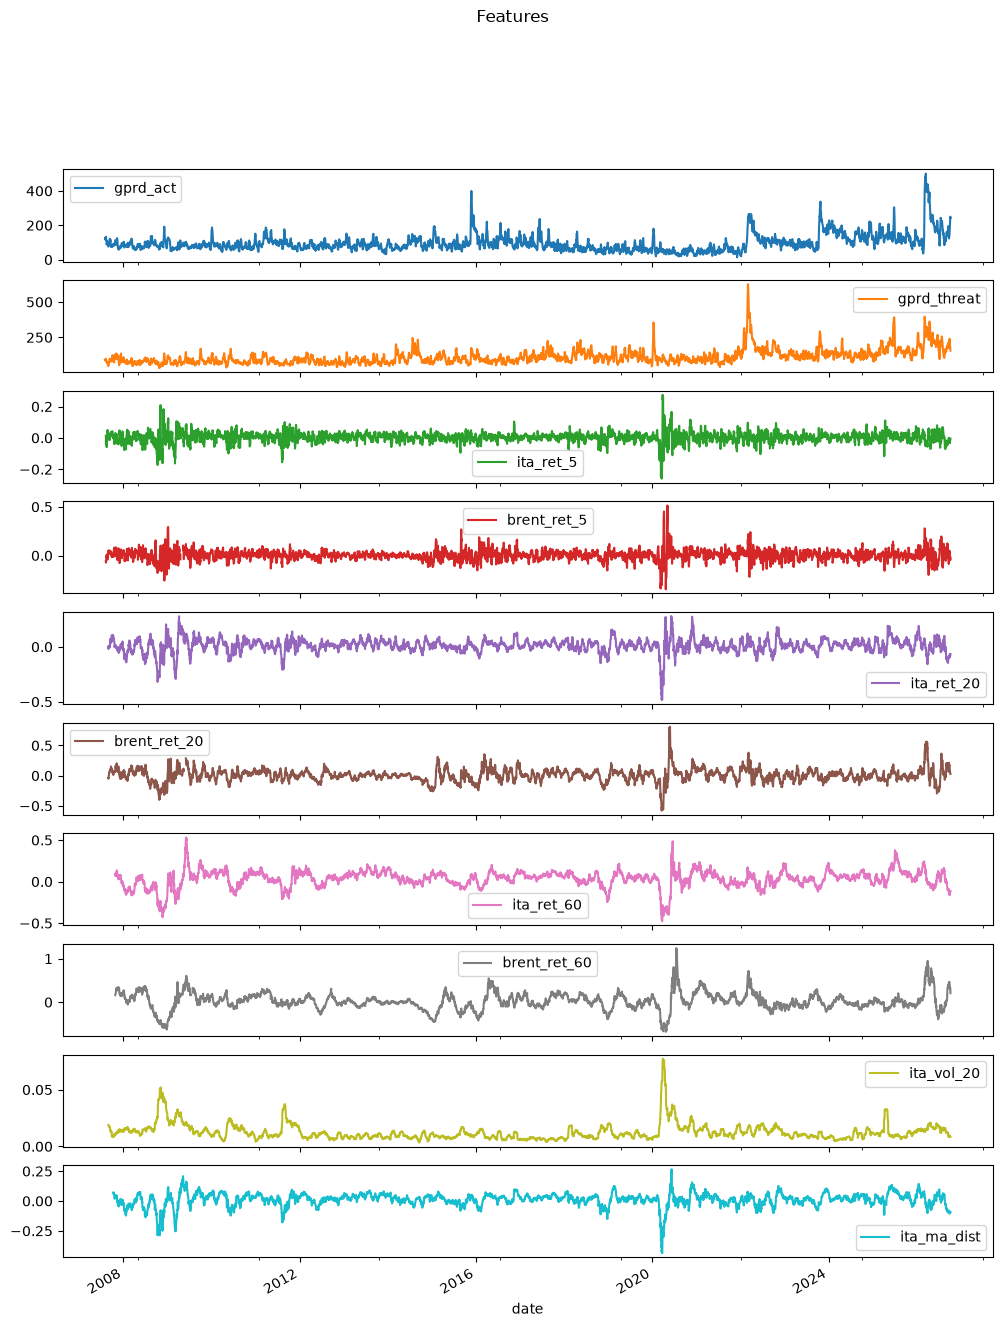

In [2]:
market = tt.features.build_market_data()
features = tt.features.build_features(market)
_ = features.plot(subplots=True, figsize=(12, 16), title="Features")

## Label

Each day is labelled by ITA's return over the next 5 trading days: **buy** (1) if it
beats half a typical 5-day move, **sell** (0) if it falls below minus that, and
**flat** (NaN) in between. The threshold scales with recent volatility, so calm and
volatile periods are treated alike. Flat days are left out of training but still
predicted and traded.

In [3]:
feature_cols = list(features)
data = features.assign(label=tt.features.build_target(market["ita"]))
data = data.loc[tt.constants.START_DATE :].dropna(subset=feature_cols)
labels = data["label"]
returns = market["ita"].pct_change()  # t-1 -> t, as backtest expects

## Models and ablation

- **xgb**: XGBoost with shallow trees (depth 3). Hyperparameters were fixed before
  the first run.
- **logit**: logistic regression on z-scored features, the baseline XGBoost has to
  beat.

Each model runs twice: with all features, and without the two GPR features
(`no_gpr`). If GPR carries information, `all` should beat `no_gpr`.

In [4]:
MODELS = {
    "xgb": XGBClassifier(
        max_depth=3,
        n_estimators=200,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
    ),
    "logit": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
}

GPR = ["gprd_act", "gprd_threat"]
FEATURE_SETS = {
    "all": feature_cols,
    "no_gpr": [c for c in feature_cols if c not in GPR],
}

## Walk-forward evaluation and backtest

Each year from 2015 is predicted by a model trained only on earlier years, with the
last 5 training days dropped so no label reaches into the test year. The predicted
probability of a buy becomes a position: long above 0.55, flat below 0.45, otherwise
hold the previous position. A position decided at day *t*'s close earns the return
from *t* to *t*+1, minus 5 bp per change in position.

How to read the table:

- `auc`: ROC AUC on labelled days, how well the probabilities rank buy days above
  sell days. 0.5 is chance; it doesn't depend on any threshold.
- `precision_buy`: of labelled days the model called a buy, the share that were
  buys. Compare it with the **base rate** printed below it; matching the base rate
  means no skill.
- `hit_rate`: share of invested days with a positive return.
- `trades`, `exposure`: number of position changes, and the share of days invested.
- `total`, `buy_hold`: total return of the strategy and of holding ITA throughout.

In [5]:
rows, runs = [], {}
for (m, model), (f, cols) in product(MODELS.items(), FEATURE_SETS.items()):
    proba = tt.evaluate.walk_forward(data, model, cols)
    res = tt.evaluate.backtest(tt.evaluate.to_positions(proba), returns)
    runs[m, f] = proba, res
    rows.append({
        "model": m,
        "features": f,
        **tt.evaluate.summarise(res, proba, labels),
    })

results = pd.DataFrame(rows).set_index(["model", "features"])
print(results.round(3))
print("base rate:", labels[str(tt.constants.FIRST_TEST_YEAR) :].mean().round(3))

                  auc  precision_buy  hit_rate  trades  exposure  total  buy_hold
model features                                                                   
xgb   all       0.505          0.588     0.536   293.0     0.710  1.070     3.081
      no_gpr    0.516          0.594     0.539   277.0     0.749  1.870     3.081
logit all       0.490          0.581     0.537    71.0     0.840  1.814     3.081
      no_gpr    0.521          0.593     0.540    53.0     0.914  3.620     3.081
base rate: 0.584


## Cumulative returns

Growth of 1 invested at the start of 2015. A strategy that is out of the market part
of the time will usually trail buy-and-hold in a rising market even with no skill, so
read this together with `exposure` in the table above.

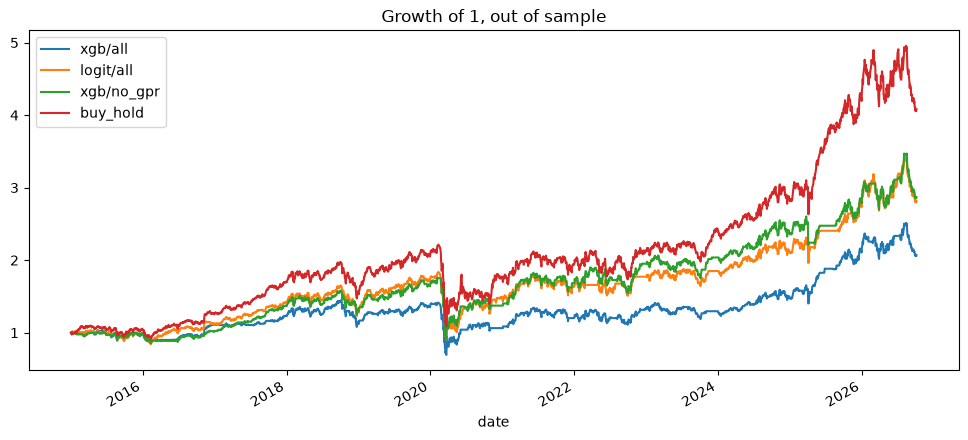

In [6]:
shown = [("xgb", "all"), ("logit", "all"), ("xgb", "no_gpr")]
cum = pd.DataFrame({
    f"{m}/{f}": (1 + runs[m, f][1]["strategy_returns"]).cumprod() for m, f in shown
})
cum["buy_hold"] = (1 + runs["xgb", "all"][1]["buy_hold"]).cumprod()
_ = cum.plot(figsize=(12, 5), title="Growth of 1, out of sample")

## Classification report

XGBoost with all features, on out-of-sample days with a buy or sell label, using a
0.5 cut-off. This scores the classifier itself; the trading rule above uses 0.55 and
0.45 instead. A macro average near 0.50 is coin-flip performance.

In [7]:
proba, res = runs["xgb", "all"]
actual = labels.reindex(proba.index)
labelled = actual.notna()
predicted = (proba[labelled] > 0.5).astype(float)
print(classification_report(actual[labelled], predicted, target_names=["sell", "buy"]))

              precision    recall  f1-score   support

        sell       0.40      0.28      0.33       765
         buy       0.58      0.70      0.63      1073

    accuracy                           0.53      1838
   macro avg       0.49      0.49      0.48      1838
weighted avg       0.50      0.53      0.51      1838



## Robustness: one day of execution delay

The same XGBoost run, traded a day late. A real timing edge should get worse with the
delay; if the result is unchanged or better, the timing is indistinguishable from
chance.

In [8]:
delayed = tt.evaluate.backtest(tt.evaluate.to_positions(proba), returns, lag=1)
print(
    pd.DataFrame({
        "lag 0": tt.evaluate.summarise(res, proba, labels),
        "lag 1": tt.evaluate.summarise(delayed, proba, labels),
    }).round(3)
)

                 lag 0    lag 1
auc              0.505    0.505
precision_buy    0.588    0.588
hit_rate         0.536    0.531
trades         293.000  293.000
exposure         0.710    0.710
total            1.070    0.980
buy_hold         3.081    3.081


## Findings

Out of sample, January 2015 to 6 October 2026, on the committed data snapshots.

**The hypothesis is not supported.**

1. **No predictive skill.** AUC is 0.49 to 0.52 for every model, where 0.5 is chance.
   Buy precision (0.58 to 0.59) matches the base rate (0.584, the share of labelled
   days that are buys), and the classification report's macro average is 0.49.
2. **GPR doesn't help.** Without GPR, AUC and precision are no worse, and total return
   is higher for both models (xgb 1.07 to 1.87, logit 1.81 to 3.62). Those gaps in
   total return are noise rather than evidence against GPR: all four runs are at
   chance, and one exit before a strong year swings the total a lot.
3. **Nothing for a delay to erode.** Trading a day late leaves AUC and precision
   unchanged and lowers XGBoost's total from 1.07 to 0.98. With no ranking skill to
   begin with, this check can't reveal a timing edge; it's a safeguard that matters
   once a model does show skill.
4. **Buy-and-hold wins, except where the strategy barely trades.** ITA returned 308%
   over the period. Only logit without GPR beats it, and it's invested 91% of the
   time, so it's close to buy-and-hold itself.

**Limits.** GPR measures how much the news covers geopolitical risk, not its tone, and
its level drifts upwards from 2022. Labels overlap because positions are re-decided
daily against a 5-day horizon. Macro conditions aren't modelled (an earlier version
with CPI, unemployment and the yield spread also scored at the base rate).

### Why a negative result is still a result

Showing that a plausible signal is noise is as useful as finding one that works. Most
ideas that look promising in hindsight don't survive an honest test, and the only way
to tell is to run them through one: a hypothesis fixed in advance, a baseline to beat,
out-of-sample evaluation, an ablation that removes the idea under test, realistic
costs, and a robustness check. Here every one of those steps came back
indistinguishable from chance, which is a clear answer to the question asked.

The pipeline is the lasting part. The same data handling, walk-forward evaluation,
backtest and ablation can test the next hypothesis (a different news measure, horizon
or asset) by changing the features, and the result will be just as trustworthy.